# 07 - CNN-BiGRU-Attention — multi-horizon

Same pipeline as notebook 07, but the model is **CNN-BiGRU-Attention** (PyTorch port of the uploaded
TensorFlow architecture, imported from `src/models/cnn_bigru_att.py`) instead of the TC-KAN /
HybridTriNet model.

Data:
- price/exogenous data: `data/processed/clean_data_exo_ver1.csv`
- scored news features: `data/news/archive_2026-06-23/combined_news_scored.csv`

Horizons evaluated: `h \in {1, 5, 10, 15, 20, 30, 60}`.

**Model.** `CNN_BiGRU_Attention` is the *temporal* port of the TF graph: 1-D convolutions over the
time window (`Conv1d(D_in->6)->ReLU->MaxPool`, `Conv1d(6->16)->ReLU->MaxPool`), a per-timestep dense
to 128, a 2-layer **bidirectional GRU** (20 units/direction), additive **attention** (size 64) over
time, then a linear output. The original TF code collapsed everything to a length-1 sequence before
the GRU (degenerate); here the time axis is preserved so the GRU/attention actually model the
sequence (matching the author's own note that the conv should be 1-D).

**Horizon.** For horizon `h` the target is the *h-step cumulative change*: from a forecast origin
`o` (K-day window ending at `o`) we predict `price[o+h]` via `price[o] + delta_h`, where
`delta_h = price[o+h] - price[o]`. A fresh model is trained per horizon (early stop on val MAPE) and
all horizons are scored on the **same final test dates**.

In [1]:
import os, sys, json, time, warnings
warnings.filterwarnings("ignore")
from dataclasses import dataclass, field
from typing import List
import numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.utils.data import DataLoader, Dataset

# import the PyTorch CNN-BiGRU-Attention from src/models (import the file directly to
# avoid the package __init__, which pulls in lightgbm/catboost).
sys.path.insert(0, os.path.abspath(os.path.join("..", "src", "models")))
from cnn_bigru_att import CNN_BiGRU_Attention

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

CSV_PATH         = "../data/processed/clean_data_exo_ver1.csv"
NEWS_SCORED_PATH = "../data/news/archive_2026-06-23/combined_news_scored.csv"
DATE_COL         = "Ng\u00e0y"
TARGET_COLS      = ["MG95", "MG92", "DO 0.001%", "DO 0.05%"]
OUT_DIR          = "../results/cnn_bigru_att/multihorizon"
os.makedirs(OUT_DIR, exist_ok=True)

Device: cuda


## Config

In [2]:
@dataclass
class CFG:
    K: int = 64
    STEP: int = 1
    val_size: int = 126
    test_size: int = 252
    batch_size: int = 64
    epochs: int = 120
    lr: float = 5e-4
    weight_decay: float = 1e-4
    lr_factor: float = 0.5
    lr_patience: int = 12
    lr_threshold: float = 1e-4
    min_lr: float = 1e-6
    patience: int = 20
    min_delta: float = 1e-4
    use_news_features: bool = True
    shift_news_days: int = 1
    news_shock_abs: float = 0.8
    news_shock_abnormal: float = 0.8
    warmup_epochs: int = 3
    loss_alpha: float = 0.2
    loss_mape_weight: float = 1.0
    mape_eps: float = 1e-3
    clip_grad: float = 5.0
    cnn_conv1: int = 6
    cnn_conv2: int = 16
    cnn_fc1: int = 128
    gru_hidden: int = 20
    gru_layers: int = 2
    attn_size: int = 64
    horizons: List[int] = field(default_factory=lambda: [1, 5, 10, 15, 20, 30, 60])

cfg = CFG()
print("horizons:", cfg.horizons, "| use_news_features:", cfg.use_news_features)

horizons: [1, 5, 10, 15, 20, 30, 60] | use_news_features: True


## Utils — features, news, split, metrics (same as notebook 06/07)

In [3]:
def set_seed(s=42):
    import random; random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)

def norm_cols(df):
    df = df.copy()
    df.columns = df.columns.astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
    return df

def add_calendar_features(df, date_col):
    df = df.copy(); d = pd.to_datetime(df[date_col])
    df["dow"]=d.dt.weekday.astype(float); df["month"]=d.dt.month.astype(float)
    df["year"]=d.dt.year.astype(float);   df["dom"]=d.dt.day.astype(float)
    return df

def _parse_day(s):
    return pd.to_datetime(s, errors="coerce", utc=True).dt.tz_convert(None).dt.normalize()

def _abs_sum(s):
    return float(np.abs(pd.to_numeric(s, errors="coerce").fillna(0.0)).sum())

def _author_style_daily_news(g, shock_abs=0.8, shock_abnormal=0.8):
    imp = pd.to_numeric(g["sentiment"], errors="coerce").dropna()
    abnormal_max = float(imp.abs().max()) if len(imp) else 0.0
    if imp.empty:
        impact_base = 0.0; shock_val = 0.0
    else:
        impact_base = float(imp.quantile([0.25, 0.50, 0.75]).mean())
        shock_val = float(imp.loc[imp.abs().idxmax()])
    use_shock = (abs(shock_val) >= float(shock_abs)) or (abnormal_max >= float(shock_abnormal))
    impact = shock_val if use_shock else impact_base
    if impact > 0:   trend = "INCREASE"
    elif impact < 0: trend = "DECREASE"
    else:            trend = "NEUTRAL"
    return pd.Series({"news_abnormal": abnormal_max, "impact_score": float(impact), "trend": trend})

def build_daily_news_features(news_path, shock_abs=0.8, shock_abnormal=0.8):
    news = norm_cols(pd.read_csv(news_path))
    date_source = "date" if "date" in news.columns else "datetime"
    required = {date_source, "topic", "sentiment"}
    missing = sorted(required - set(news.columns))
    if missing:
        raise ValueError(f"News file is missing columns: {missing}")
    news["date"] = _parse_day(news[date_source])
    news["topic"] = news["topic"].astype(str).str.strip()
    news["sentiment"] = pd.to_numeric(news["sentiment"], errors="coerce")
    news = news.dropna(subset=["date", "sentiment"]).copy()
    if news.empty:
        return pd.DataFrame(columns=["date", "news_abnormal", "impact_score", "trend"])
    daily_index = pd.DataFrame({"date": pd.date_range(news["date"].min(), news["date"].max(), freq="D")})
    topic_daily = (news.groupby(["date", "topic"])["sentiment"]
                       .agg(n="count", sent_mean="mean", sent_sum="sum", intensity=_abs_sum).reset_index())
    topic_wide = topic_daily.pivot(index="date", columns="topic", values=["n", "sent_mean", "sent_sum", "intensity"])
    topic_wide.columns = [f"{topic}_{metric}" for metric, topic in topic_wide.columns]
    topic_wide = topic_wide.reset_index()
    all_daily = (news.groupby("date")["sentiment"]
                     .agg(all_n="count", all_sent_mean="mean", all_sent_sum="sum", all_intensity=_abs_sum).reset_index())
    author_daily = (news.groupby("date")
                        .apply(lambda g: _author_style_daily_news(g, shock_abs=shock_abs, shock_abnormal=shock_abnormal))
                        .reset_index())
    daily = daily_index.merge(topic_wide, on="date", how="left").merge(all_daily, on="date", how="left").merge(author_daily, on="date", how="left")
    numeric_cols = [c for c in daily.columns if c not in ("date", "trend")]
    daily[numeric_cols] = daily[numeric_cols].fillna(0.0)
    daily["trend"] = daily["trend"].fillna("NEUTRAL")
    return daily

def prep_news(df, shift_days=1, news_cols=None):
    df = df.copy()
    if news_cols is None:
        news_cols = ["news_abnormal", "impact_score"]
    for c in news_cols:
        if c not in df.columns: df[c] = 0.0
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0.0)
    if shift_days > 0 and news_cols:
        df[news_cols] = df[news_cols].shift(shift_days).fillna(0.0)
    return df

def merge_news_features(df, date_col, news_path, shift_days=1, shock_abs=0.8, shock_abnormal=0.8):
    daily = build_daily_news_features(news_path, shock_abs=shock_abs, shock_abnormal=shock_abnormal)
    if daily.empty:
        return prep_news(df, shift_days=shift_days)
    out = df.merge(daily, how="left", left_on=date_col, right_on="date").drop(columns=["date"])
    news_cols = [c for c in daily.columns if c not in ("date", "trend")]
    for c in news_cols:
        out[c] = pd.to_numeric(out[c], errors="coerce").fillna(0.0)
    out["trend"] = out["trend"].fillna("NEUTRAL")
    out = prep_news(out, shift_days=shift_days, news_cols=news_cols)
    print(f"merged {len(news_cols)} numeric news features from {daily['date'].min().date()} "
          f"to {daily['date'].max().date()} | shifted by {shift_days} day(s)")
    return out

def fill_missing(df, date_col):
    df = df.copy()
    for c in df.columns:
        if c != date_col and pd.api.types.is_numeric_dtype(df[c]):
            df[c] = pd.to_numeric(df[c], errors="coerce").ffill().bfill()
    return df

def time_split(T, K, val_size, test_size):
    te_e=T; te_s=max(0,T-test_size); va_e=te_s; va_s=max(0,va_e-val_size); tr_e=max(va_s,K+1)
    return (0,tr_e),(va_s,va_e),(te_s,te_e)

def mape(yp, yt, eps=1e-6):
    if yp is None or len(yp)==0: return float("nan")
    yp=np.asarray(yp,np.float32); yt=np.asarray(yt,np.float32)
    return float(np.mean(np.abs(yp-yt)/(np.abs(yt)+eps))*100)

def per_target_metrics(Yp, Yt):
    out={}
    for j,c in enumerate(TARGET_COLS):
        yp,yt=Yp[:,j],Yt[:,j]; ss=float(np.sum((yt-yt.mean())**2))
        out[c]=dict(MAE=round(float(np.mean(np.abs(yp-yt))),4),
                    RMSE=round(float(np.sqrt(np.mean((yp-yt)**2))),4),
                    MAPE=round(float(np.mean(np.abs(yp-yt)/(np.abs(yt)+1e-6))*100),4),
                    SMAPE=round(float(np.mean(2*np.abs(yp-yt)/(np.abs(yp)+np.abs(yt)+1e-6))*100),4),
                    R2=round(float(1-np.sum((yt-yp)**2)/(ss+1e-12)),4))
    return out

## Dataset, EMA, horizon-aware price reconstruction

`WindowDeltaDataset` and `collect_price_preds` take a horizon `H`. The K-day input window ends at the
forecast origin `o = t - H`; the (scaled) target is `price[t] - price[o]`, and the price is
reconstructed as `price[o] + delta_H`. The model itself is `CNN_BiGRU_Attention` imported above.

In [4]:
class WindowDeltaDataset(Dataset):
    def __init__(self, Xs, Ys, K, H, start, end, step=1):
        self.Xs, self.Ys, self.K, self.H = Xs, Ys, int(K), int(H)
        lo = max(self.K + self.H - 1, start)
        self.t_list = list(range(lo, end, max(1, int(step))))
    def __len__(self): return len(self.t_list)
    def __getitem__(self, i):
        t = self.t_list[i]; H, K = self.H, self.K
        x = self.Xs[t-H-K+1 : t-H+1]          # K steps ending at origin o = t-H
        return torch.from_numpy(x).float(), torch.from_numpy(self.Ys[t]).float()

class EMA:
    def __init__(self, model, decay=0.999):
        self.decay=decay; self.backup=None
        self.shadow={k:v.detach().clone() for k,v in model.state_dict().items() if torch.is_tensor(v)}
    @torch.no_grad()
    def update(self, model):
        for k,v in model.state_dict().items():
            if torch.is_tensor(v):
                if k in self.shadow: self.shadow[k].mul_(self.decay).add_(v.detach(), alpha=1-self.decay)
                else: self.shadow[k]=v.detach().clone()
    @torch.no_grad()
    def apply(self, model):
        self.backup={k:v.detach().clone() for k,v in model.state_dict().items() if torch.is_tensor(v)}
        for k,v in model.state_dict().items():
            if torch.is_tensor(v): v.copy_(self.shadow[k])
    @torch.no_grad()
    def restore(self, model):
        if self.backup is None: return
        for k,v in model.state_dict().items():
            if torch.is_tensor(v) and k in self.backup: v.copy_(self.backup[k])
        self.backup=None

@torch.no_grad()
def collect_price_preds(model, Xs, df, fc, K, H, start, end, X_MEAN, X_STD, Y_MEAN, Y_STD):
    ti=[fc.index(c) for c in TARGET_COLS]
    xmt=torch.tensor(X_MEAN[ti],device=DEVICE); xst=torch.tensor(X_STD[ti],device=DEVICE)
    ymt=torch.tensor(Y_MEAN,device=DEVICE);     yst=torch.tensor(Y_STD,device=DEVICE)
    P,Tr=[],[]
    for t in range(max(K+H-1,start), end):
        x = Xs[t-H-K+1 : t-H+1]
        xb=torch.from_numpy(x).float().unsqueeze(0).to(DEVICE)
        pp=(xb[:,-1,ti]*xst+xmt)+(model(xb)*yst+ymt)   # price[o] + delta_H
        P.append(pp.squeeze(0).cpu().numpy()); Tr.append(df.loc[t,TARGET_COLS].values.astype(np.float32))
    if not P: return np.zeros((0,4),np.float32), np.zeros((0,4),np.float32)
    return np.stack(P).astype(np.float32), np.stack(Tr).astype(np.float32)

## Load data, build features, split, scale X (shared across horizons)

In [5]:
set_seed(42)
df = norm_cols(pd.read_csv(CSV_PATH))
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
df = df.dropna(subset=[DATE_COL]).sort_values(DATE_COL).reset_index(drop=True)
df = add_calendar_features(df, DATE_COL)
if cfg.use_news_features:
    df = merge_news_features(df, DATE_COL, NEWS_SCORED_PATH, shift_days=cfg.shift_news_days,
                             shock_abs=cfg.news_shock_abs, shock_abnormal=cfg.news_shock_abnormal)
else:
    df = prep_news(df, cfg.shift_news_days)
df = fill_missing(df, DATE_COL)
for c in TARGET_COLS: df[c] = df[c].ffill().bfill()

feature_cols = [c for c in df.columns if c not in (DATE_COL, "trend") and pd.api.types.is_numeric_dtype(df[c])]
for c in TARGET_COLS:
    if c not in feature_cols: feature_cols.append(c)
news_feature_cols = [c for c in feature_cols if c in ("news_abnormal", "impact_score")
                     or c.endswith(("_n", "_sent_mean", "_sent_sum", "_intensity"))]

X = df[feature_cols].values.astype(np.float32); T, D_in = X.shape
(tr0,tr1),(va0,va1),(te0,te1) = time_split(T, cfg.K, cfg.val_size, cfg.test_size)
print(f"T={T} D_in={D_in} K={cfg.K} | train={tr1-tr0} val={va1-va0} test={te1-te0} "
      f"| features={len(feature_cols)} | news_features={len(news_feature_cols)}")
print("news feature columns:", news_feature_cols[:12], "..." if len(news_feature_cols) > 12 else "")

# z-score X (fit on train only) — shared across all horizons
X_MEAN = X[:tr1].mean(0).astype(np.float32); X_STD = (X[:tr1].std(0)+1e-8).astype(np.float32)
Xs = (X - X_MEAN) / X_STD

merged 18 numeric news features from 2008-05-01 to 2026-05-08 | shifted by 1 day(s)
T=4649 D_in=39 K=64 | train=4271 val=126 test=252 | features=39 | news_features=18
news feature columns: ['natural_disaster_n', 'political_economy_n', 'war_n', 'natural_disaster_sent_mean', 'political_economy_sent_mean', 'war_sent_mean', 'natural_disaster_sent_sum', 'political_economy_sent_sum', 'war_sent_sum', 'natural_disaster_intensity', 'political_economy_intensity', 'war_intensity'] ...


## Train + evaluate one horizon

Same training recipe as notebook 06/07 (delta + MAPE loss, EMA, ReduceLROnPlateau, early stop on val
MAPE). Only the model differs.

In [6]:
def train_eval_horizon(H, verbose=True):
    set_seed(42)
    # h-step delta targets, scaled on train only
    Yd = np.stack([df[c].diff(H).fillna(0.0).values.astype(np.float32) for c in TARGET_COLS], axis=1)
    Y_MEAN = Yd[:tr1].mean(0).astype(np.float32); Y_STD = (Yd[:tr1].std(0)+1e-8).astype(np.float32)
    Ys = (Yd - Y_MEAN) / Y_STD

    dl_tr = DataLoader(WindowDeltaDataset(Xs, Ys, cfg.K, H, tr0, tr1, cfg.STEP),
                       batch_size=cfg.batch_size, shuffle=True)

    ti = [feature_cols.index(c) for c in TARGET_COLS]
    xmt=torch.tensor(X_MEAN[ti],device=DEVICE); xst=torch.tensor(X_STD[ti],device=DEVICE)
    ymt=torch.tensor(Y_MEAN,device=DEVICE);     yst=torch.tensor(Y_STD,device=DEVICE)

    model = CNN_BiGRU_Attention(D_in, len(TARGET_COLS), seq_len=cfg.K,
                                conv1=cfg.cnn_conv1, conv2=cfg.cnn_conv2, fc1=cfg.cnn_fc1,
                                gru_hidden=cfg.gru_hidden, gru_layers=cfg.gru_layers,
                                attn_size=cfg.attn_size).to(DEVICE)
    ema = EMA(model, 0.999)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, "min", factor=cfg.lr_factor,
            patience=cfg.lr_patience, threshold=cfg.lr_threshold, min_lr=cfg.min_lr)

    best=float("inf"); best_ep=0; bad=0; va_ema=None
    ck = os.path.join(OUT_DIR, f"best_h{H}.pth")
    t0 = time.time()
    for ep in range(cfg.epochs):
        model.train()
        if ep < cfg.warmup_epochs:
            for pg in opt.param_groups: pg["lr"] = cfg.lr*(ep+1)/max(1,cfg.warmup_epochs)
        for xb, yb in dl_tr:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            ps = model(xb)
            delta_loss = torch.mean(torch.abs(ps - yb))
            lp = xb[:,-1,ti]*xst+xmt
            pp = lp + ps*yst+ymt; tp = lp + yb*yst+ymt
            mape_loss = torch.mean(torch.abs(pp-tp)/(torch.abs(tp)+cfg.mape_eps))
            loss = cfg.loss_alpha*delta_loss + cfg.loss_mape_weight*mape_loss
            opt.zero_grad(set_to_none=True); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.clip_grad); opt.step(); ema.update(model)
        ema.apply(model); model.eval()
        Yp, Yt = collect_price_preds(model, Xs, df, feature_cols, cfg.K, H, va0, va1, X_MEAN, X_STD, Y_MEAN, Y_STD)
        vm = mape(Yp, Yt)
        va_ema = vm if va_ema is None else 0.9*va_ema + 0.1*vm
        if vm < best - cfg.min_delta: best=vm; best_ep=ep+1; bad=0; torch.save(model.state_dict(), ck)
        else: bad += 1
        ema.restore(model)
        if ep >= cfg.warmup_epochs and np.isfinite(va_ema): sch.step(va_ema)
        if bad >= cfg.patience:
            break

    model.load_state_dict(torch.load(ck, map_location=DEVICE))
    Yp_va, Yt_va = collect_price_preds(model, Xs, df, feature_cols, cfg.K, H, va0, va1, X_MEAN, X_STD, Y_MEAN, Y_STD)
    Yp_te, Yt_te = collect_price_preds(model, Xs, df, feature_cols, cfg.K, H, te0, te1, X_MEAN, X_STD, Y_MEAN, Y_STD)
    res_te = per_target_metrics(Yp_te, Yt_te); res_va = per_target_metrics(Yp_va, Yt_va)
    out = {"horizon": H, "best_epoch": best_ep, "n_test": int(len(Yp_te)),
           "test_overall_mape": mape(Yp_te, Yt_te), "val_overall_mape": mape(Yp_va, Yt_va),
           "test_per_target": res_te, "val_per_target": res_va, "train_sec": round(time.time()-t0, 1)}
    if verbose:
        print(f"h={H:>3} | best ep {best_ep:>3} | test MAPE {out['test_overall_mape']:.4f}% "
              f"| val MAPE {out['val_overall_mape']:.4f}% | {out['train_sec']}s | n_test={out['n_test']}")
    return out

## Run all horizons

In [7]:
all_results = {}
for H in cfg.horizons:
    all_results[H] = train_eval_horizon(H)

json.dump(all_results, open(os.path.join(OUT_DIR, "multihorizon_results.json"), "w"), indent=2)
print("\nsaved ->", os.path.join(OUT_DIR, "multihorizon_results.json"))

h=  1 | best ep  14 | test MAPE 2.0310% | val MAPE 1.1450% | 18.5s | n_test=252
h=  5 | best ep   9 | test MAPE 4.9374% | val MAPE 2.9811% | 15.5s | n_test=252
h= 10 | best ep   5 | test MAPE 7.1215% | val MAPE 3.9753% | 13.0s | n_test=252
h= 15 | best ep   3 | test MAPE 9.1124% | val MAPE 4.0245% | 12.4s | n_test=252
h= 20 | best ep   9 | test MAPE 10.7373% | val MAPE 4.5672% | 14.8s | n_test=252
h= 30 | best ep  12 | test MAPE 11.9503% | val MAPE 5.3350% | 17.0s | n_test=252
h= 60 | best ep   6 | test MAPE 14.1654% | val MAPE 7.2030% | 13.2s | n_test=252

saved -> ../results/cnn_bigru_att/multihorizon\multihorizon_results.json


## Summary table — overall + per-target test MAPE by horizon

In [8]:
rows = []
for H in cfg.horizons:
    r = all_results[H]
    row = {"horizon": H, "best_epoch": r["best_epoch"],
           "test_MAPE_overall": round(r["test_overall_mape"], 4),
           "val_MAPE_overall": round(r["val_overall_mape"], 4)}
    for c in TARGET_COLS:
        row[f"{c}_MAPE"] = r["test_per_target"][c]["MAPE"]
    rows.append(row)
summary = pd.DataFrame(rows).set_index("horizon")
summary.to_csv(os.path.join(OUT_DIR, "multihorizon_summary.csv"))
print("saved ->", os.path.join(OUT_DIR, "multihorizon_summary.csv"))
display(summary)

saved -> ../results/cnn_bigru_att/multihorizon\multihorizon_summary.csv


,best_epoch,test_MAPE_overall,val_MAPE_overall,MG95_MAPE,MG92_MAPE,DO 0.001%_MAPE,DO 0.05%_MAPE
horizon,,,,,,,
1,14,2.0310,1.1450,1.7667,1.7665,2.2842,2.3064
5,9,4.9374,2.9811,4.2925,4.1270,5.6130,5.7171
10,5,7.1215,3.9753,5.5930,5.3846,8.6842,8.8241
15,3,9.1124,4.0245,7.0715,6.8154,11.2406,11.3221
20,9,10.7373,4.5672,8.4208,7.8941,13.3039,13.3304
30,12,11.9503,5.3350,10.1584,9.5583,14.1594,13.9250
60,6,14.1654,7.2030,12.4704,11.7309,16.6953,15.7651


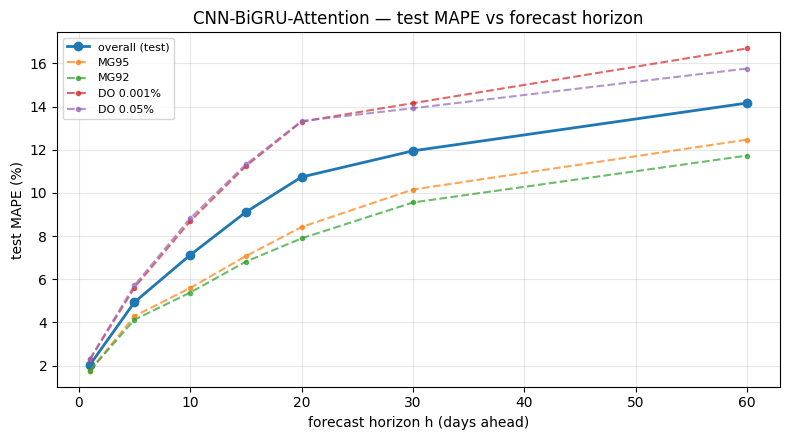

In [9]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(summary.index, summary["test_MAPE_overall"], "o-", lw=2, label="overall (test)")
for c in TARGET_COLS:
    ax.plot(summary.index, summary[f"{c}_MAPE"], ".--", alpha=0.7, label=c)
ax.set_xlabel("forecast horizon h (days ahead)"); ax.set_ylabel("test MAPE (%)")
ax.set_title("CNN-BiGRU-Attention — test MAPE vs forecast horizon"); ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Notes

- Model is `CNN_BiGRU_Attention` from `src/models/cnn_bigru_att.py` (PyTorch port of the uploaded TF
  architecture, temporal variant: 1-D conv over time -> BiGRU over the sequence -> attention over
  time -> linear). Tune CNN/GRU/attention sizes via the `cfg.cnn_*`, `cfg.gru_*`, `cfg.attn_size`.
- Everything else (news merge, delta targets, training loop, splits, metrics) is identical to
  notebook 07, so results are directly comparable model-for-model.
- One fresh model per horizon; all scored on the **same final test dates**. The model predicts the
  **h-step cumulative price change** and reconstructs the price level; metrics are on the price.
- News features come from `data/news/archive_2026-06-23/combined_news_scored.csv`, merged on date and
  shifted by `cfg.shift_news_days`. Set `cfg.use_news_features = False` to disable.
- Outputs go to `results/cnn_bigru_att/multihorizon/`.